# Import Dependency

In [1]:
import os
import shutil
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
from copy import deepcopy
from dataclasses import dataclass, field

In [2]:
# import sys
# !{sys.executable} -m pip install seaborn

In [3]:
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.max_columns', None)

# Read Dataset

In [4]:
candidate_base_dirs = ["dataset", "CASME2", "CASME II"]
base_dir = next((p for p in candidate_base_dirs if os.path.isdir(p)), "dataset")

data = []
labels = []
groups = []
categories = ['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise']

if not os.path.isdir(base_dir):
    raise FileNotFoundError(
        f"Folder dataset tidak ditemukan. Cek salah satu folder ini di root project: {candidate_base_dirs}"
    )

df_meta = pd.read_excel('CASME2-INFO.xlsx')
df_meta.columns = df_meta.columns.str.strip()


def find_frame_path(seq_path, frame_idx):
    """Cari file frame dengan dua pola penamaan (imgN.jpg / imgNNN.jpg)."""
    for cand in (f"img{frame_idx}.jpg", f"img{frame_idx:03d}.jpg"):
        p = os.path.join(seq_path, cand)
        if os.path.exists(p):
            return p
    return None


def compute_optical_flow(onset_bgr, apex_bgr):
    """Optical flow Farneback onset -> apex.
    Output 3 kanal uint8 [flow_x, flow_y, magnitude] agar kompatibel
    dengan backbone pretrained ImageNet (input 3 channel)."""
    g1 = cv2.cvtColor(onset_bgr, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(apex_bgr, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        g1, g2, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )
    fx, fy = flow[..., 0], flow[..., 1]
    mag = np.sqrt(fx ** 2 + fy ** 2)

    def to_uint8(ch):
        return cv2.normalize(ch, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return np.stack([to_uint8(fx), to_uint8(fy), to_uint8(mag)], axis=-1)


skipped = 0
for index, row in df_meta.iterrows():
    total_rows += 1
    subject = str(row['Subject']).zfill(2)
    filename = str(row['Filename']).strip()
    onset = row['OnsetFrame']
    apex = row['ApexFrame']
    emotion = str(row['Estimated Emotion']).strip().lower()

    if emotion not in categories:
        continue
    if pd.isna(apex) or str(apex).strip() == '/':
        continue
    if pd.isna(onset) or str(onset).strip() == '/':
        continue

    onset_frame = int(onset)
    apex_frame = int(apex)
    seq_path = os.path.join(base_dir, f"sub{subject}", filename)
    if not os.path.exists(seq_path):
        continue

    onset_path = find_frame_path(seq_path, onset_frame)
    apex_path = find_frame_path(seq_path, apex_frame)
    if onset_path is None or apex_path is None:
        skipped += 1
        continue

    onset_img = cv2.imread(onset_path)
    apex_img = cv2.imread(apex_path)
    if onset_img is None or apex_img is None:
        skipped += 1
        continue

    if onset_img.shape != apex_img.shape:
        apex_img = cv2.resize(apex_img, (onset_img.shape[1], onset_img.shape[0]))

    flow_img = compute_optical_flow(onset_img, apex_img)
    data.append(flow_img)
    labels.append(emotion)
    groups.append(subject)

print(f"Total sampel optical flow: {len(data)} | dilewati (frame hilang): {skipped}")

Total sampel optical flow: 254 | dilewati (frame hilang): 0


# EDA

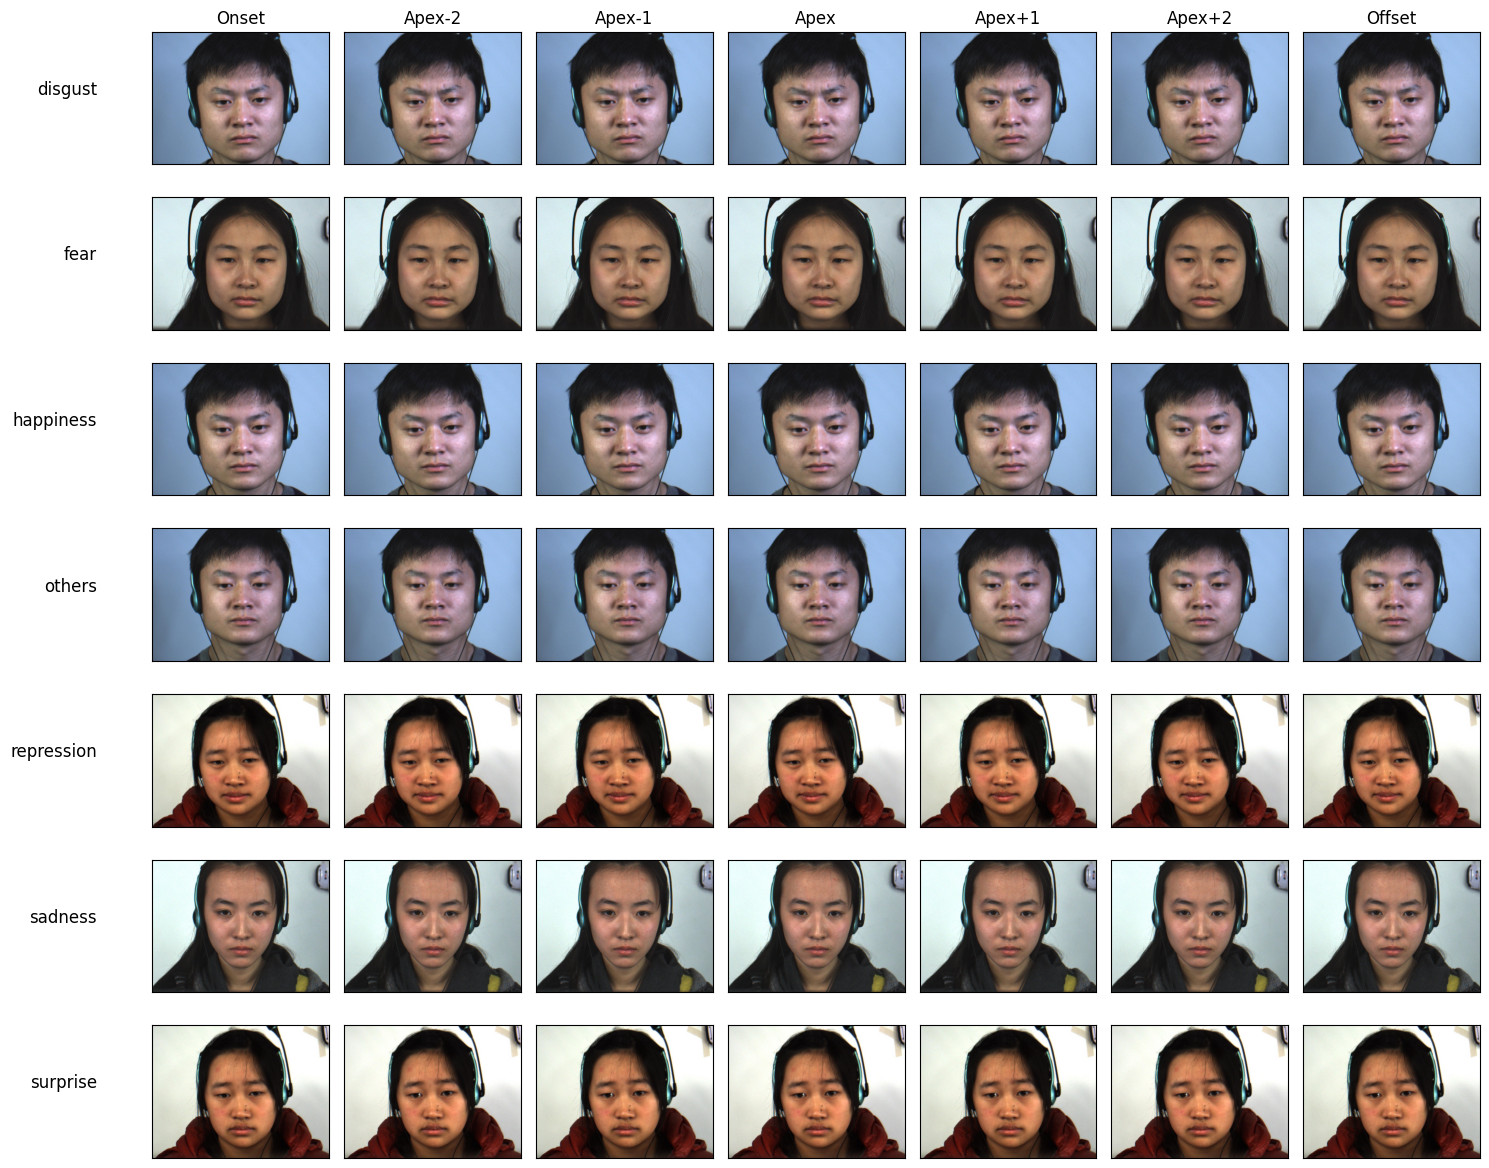

In [5]:
df_meta.columns = df_meta.columns.str.strip()
df_meta['Estimated Emotion'] = df_meta['Estimated Emotion'].astype(str).str.strip().str.lower()

plt.figure(figsize=(15, 12))
titles = ["Onset", "Apex-2", "Apex-1", "Apex", "Apex+1", "Apex+2", "Offset"]

for row_idx, category in enumerate(categories):
    match = df_meta[df_meta['Estimated Emotion'] == category]
    
    valid_rows = match[
        ~match['OnsetFrame'].astype(str).str.contains('/') & 
        ~match['ApexFrame'].astype(str).str.contains('/') & 
        ~match['OffsetFrame'].astype(str).str.contains('/')
    ]
    
    if not valid_rows.empty:
        first_match = valid_rows.iloc[0]
        subject = str(first_match['Subject']).zfill(2)
        filename = str(first_match['Filename']).strip()
        
        apex_frame = int(first_match['ApexFrame'])
        onset_frame = int(first_match['OnsetFrame'])
        offset_frame = int(first_match['OffsetFrame'])
        
        seq_path = os.path.join(base_dir, f"sub{subject}", filename)
        
        target_frames = [
            onset_frame, 
            max(onset_frame, apex_frame - 2), 
            max(onset_frame, apex_frame - 1), 
            apex_frame, 
            min(offset_frame, apex_frame + 1), 
            min(offset_frame, apex_frame + 2), 
            offset_frame
        ]
        
        for col_idx, target_frame in enumerate(target_frames):
            img_path = os.path.join(seq_path, f"img{target_frame}.jpg")
            if not os.path.exists(img_path):
                img_path = os.path.join(seq_path, f"img{target_frame:03d}.jpg")
                
            plt.subplot(len(categories), len(titles), row_idx * len(titles) + col_idx + 1)
            
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            
            if col_idx == 0:
                plt.ylabel(category, fontsize=12, rotation=0, labelpad=40, ha='right')
            
            if row_idx == 0:
                plt.title(titles[col_idx])
                    
            plt.xticks([])
            plt.yticks([])

plt.tight_layout()
plt.show()

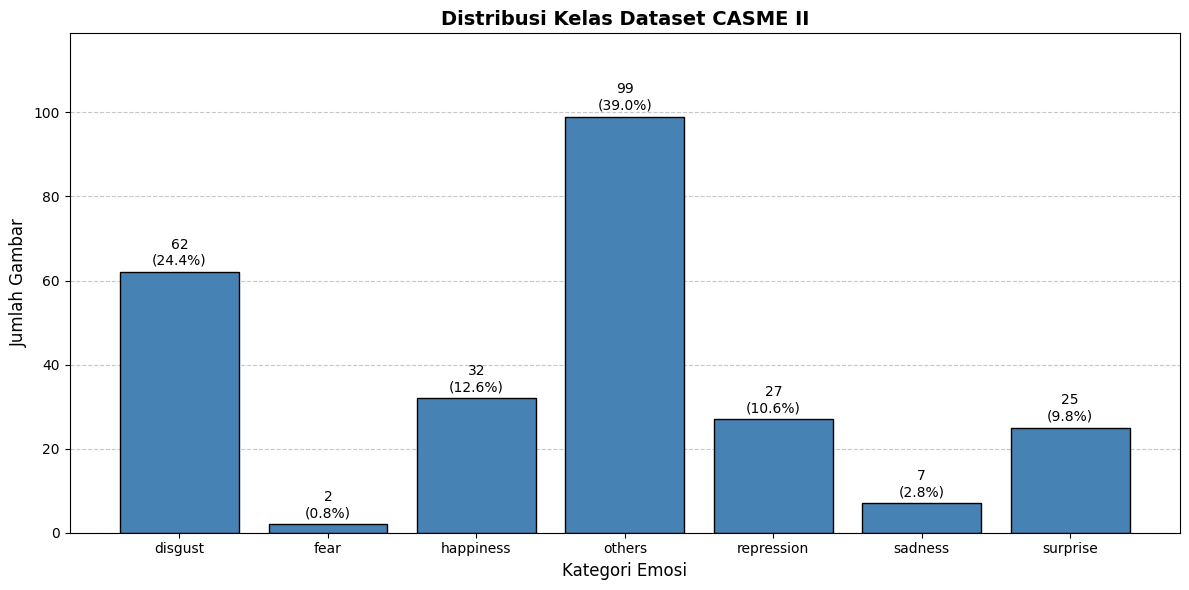

In [6]:
counts = Counter(labels)
frequencies = [counts[category] for category in categories]
total_data = sum(frequencies)

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, frequencies, color='steelblue', edgecolor='black', zorder=2)

for bar in bars:
    yval = bar.get_height()
    percentage = f"{(yval / total_data) * 100:.1f}%" if total_data > 0 else "0%"
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval}\n({percentage})", ha='center', va='bottom', fontsize=10)

plt.title('Distribusi Kelas Dataset CASME II', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Emosi', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.ylim(0, max(frequencies) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()

In [7]:
dist_data = []

for category in categories:
    pct = (counts[category] / len(labels)) * 100 if len(labels) > 0 else 0
    dist_data.append({
        "Kategori": category,
        "Jumlah Gambar": counts[category],
        "Persentase": f"{pct:.1f}%"
    })

dist_data.append({
    "Kategori": "Total",
    "Jumlah Gambar": len(labels),
    "Persentase": "100.0%"
})

df_dist = pd.DataFrame(dist_data)
display(df_dist)

## Distribusi Durasi Dataset

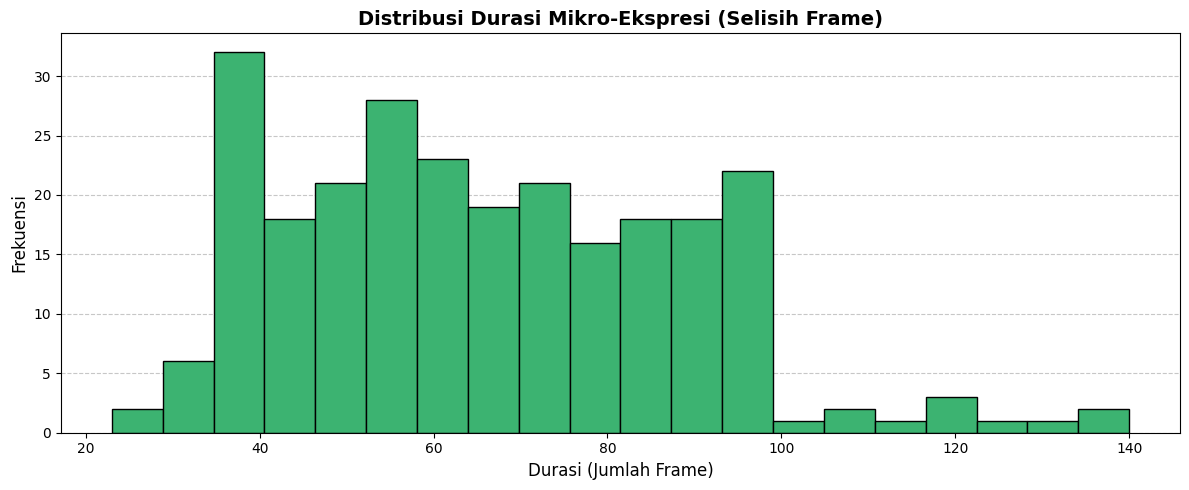

In [8]:
valid_duration = df_meta[
    ~df_meta['OnsetFrame'].astype(str).str.contains('/') & 
    ~df_meta['OffsetFrame'].astype(str).str.contains('/')
].copy()

valid_duration['Duration'] = valid_duration['OffsetFrame'].astype(int) - valid_duration['OnsetFrame'].astype(int)

plt.figure(figsize=(12, 5))
plt.hist(valid_duration['Duration'], bins=20, color='mediumseagreen', edgecolor='black', zorder=2)
plt.title('Distribusi Durasi Mikro-Ekspresi (Selisih Frame)', fontsize=14, fontweight='bold')
plt.xlabel('Durasi (Jumlah Frame)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()

In [9]:
dur_bins = pd.cut(valid_duration['Duration'], bins=10)
dur_counts = dur_bins.value_counts().sort_index()

dur_table_data = []
for interval, count in dur_counts.items():
    pct = (count / len(valid_duration)) * 100 if len(valid_duration) > 0 else 0
    dur_table_data.append({
        "Rentang Durasi (Frame)": f"{int(round(interval.left))} - {int(round(interval.right))}",
        "Jumlah Sampel": count,
        "Persentase": f"{pct:.1f}%"
    })

df_dur_dist = pd.DataFrame(dur_table_data)
display(df_dur_dist)

## Class Tiap Subjek

In [10]:
df_subject_class = pd.crosstab(
    pd.Series(groups, name='Subjek'), 
    pd.Series(labels, name='Kategori Emosi'),
    margins=True,
    margins_name='Total'
)

display(df_subject_class)

## Corrupt File

In [11]:
corrupted_files = []

for root, _, files in os.walk(base_dir):
    for file_name in files:
        if file_name.endswith('.jpg'):
            img_path = os.path.join(root, file_name)
            try:
                with open(img_path, 'rb') as f:
                    f.seek(-2, 2)
                    if f.read() != b'\xff\xd9':
                        corrupted_files.append(img_path)
            except Exception:
                corrupted_files.append(img_path)

print("Jumlah file rusak ditemukan:", len(corrupted_files))
if len(corrupted_files) > 0:
    for f_path in corrupted_files:
        print(f_path)

# GPU SETUP

In [12]:
import torch

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    device = torch.device("cuda")
    x = torch.ones(3, 3).to(device)
    print("Running on GPU")
else:
    device = torch.device("cpu")
    print("Running on CPU")

# Preparation

## Definisi Struktur Dasar (Kromosom GA, Dataset, Tight Hybrid + Backbone Pretrained)

In [13]:
# Channel fitur backbone (ResNet18 layer3) -> menentukan ukuran GA mask
MASK_DIM = 256

label_mapping = {cat: i for i, cat in enumerate(
    ['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise'])}


@dataclass
class GAChromosome:
    mask_logits: np.ndarray = field(default_factory=lambda: np.random.randn(MASK_DIM) * 0.1)
    num_heads: int = 4
    mixer_depth: int = 4
    dropout: float = 0.2
    lr: float = 1e-3

    @staticmethod
    def random():
        return GAChromosome(
            mask_logits=np.random.randn(MASK_DIM) * 0.1,
            num_heads=int(np.random.choice([2, 4, 8])),   # harus membagi 256
            mixer_depth=int(np.random.choice([2, 3, 4])),
            dropout=float(np.random.uniform(0.1, 0.35)),
            lr=float(np.random.choice([1e-4, 5e-4, 1e-3])),
        )

    def crossover(self, other: "GAChromosome"):
        cp = np.random.randint(1, MASK_DIM)
        def pick(a, b): return a if np.random.rand() < 0.5 else b
        c1 = GAChromosome(
            mask_logits=np.concatenate([self.mask_logits[:cp], other.mask_logits[cp:]]),
            num_heads=pick(self.num_heads, other.num_heads),
            mixer_depth=pick(self.mixer_depth, other.mixer_depth),
            dropout=(self.dropout + other.dropout) / 2,
            lr=pick(self.lr, other.lr),
        )
        c2 = GAChromosome(
            mask_logits=np.concatenate([other.mask_logits[:cp], self.mask_logits[cp:]]),
            num_heads=pick(other.num_heads, self.num_heads),
            mixer_depth=pick(other.mixer_depth, self.mixer_depth),
            dropout=(self.dropout + other.dropout) / 2,
            lr=pick(other.lr, self.lr),
        )
        return c1, c2

    def mutate(self, rate: float = 0.1):
        self.mask_logits = self.mask_logits + np.random.randn(MASK_DIM) * rate
        if np.random.rand() < rate:
            self.num_heads = int(np.random.choice([2, 4, 8]))
        if np.random.rand() < rate:
            self.mixer_depth = int(np.random.choice([2, 3, 4]))
        if np.random.rand() < 0.3:
            self.dropout = float(np.clip(self.dropout + np.random.randn() * 0.05, 0.05, 0.5))
        if np.random.rand() < rate:
            self.lr = float(np.random.choice([1e-4, 5e-4, 1e-3]))


class MicroExpressionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.label_mapping = label_mapping

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.label_mapping[self.labels[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label


class TightHybridGA(nn.Module):
    """Tight Hybrid + GA dengan backbone pretrained.

    Alur: ResNet18(layer3, pretrained) -> GA channel-mask -> depthwise/pointwise
    mixer (tight, kedalaman dikendalikan GA) -> Transformer encoder -> head.
    Backbone partial fine-tune: hanya layer3 yang dilatih, sisanya beku.
    """
    def __init__(self, num_classes=7, mixer_depth=4, num_heads=4, mlp_dim=256, dropout=0.3):
        super().__init__()
        self.mixer_depth = mixer_depth
        self.patch_size = 4

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Fitur sampai layer2 (beku) dan layer3 (di-fine-tune)
        self.backbone_frozen = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2,
        )
        self.backbone_tune = backbone.layer3
        dim = MASK_DIM  # 256

        for p in self.backbone_frozen.parameters():
            p.requires_grad = False
        for p in self.backbone_tune.parameters():
            p.requires_grad = True

        # ---- Komponen GA + Tight Hybrid ----
        self.ga_mask = nn.Parameter(torch.zeros(dim))
        self.depthwise_convs = nn.ModuleList([nn.Conv2d(dim, dim, 3, groups=dim, padding=1) for _ in range(mixer_depth)])
        self.batch_norms_dw = nn.ModuleList([nn.BatchNorm2d(dim) for _ in range(mixer_depth)])
        self.pointwise_convs = nn.ModuleList([nn.Conv2d(dim, dim, kernel_size=1) for _ in range(mixer_depth)])
        self.batch_norms_pw = nn.ModuleList([nn.BatchNorm2d(dim) for _ in range(mixer_depth)])
        self.gelu = nn.GELU()
        self.feature_align = nn.AdaptiveAvgPool2d((16, 16))
        self.patch_embed = nn.Conv2d(dim, dim, kernel_size=self.patch_size, stride=self.patch_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=num_heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head_dropout = nn.Dropout(dropout)
        self.mlp_head = nn.Linear(dim, num_classes)

    def init_from_chromosome(self, chrom: GAChromosome):
        with torch.no_grad():
            self.ga_mask.data = torch.tensor(chrom.mask_logits, dtype=torch.float32).to(self.ga_mask.device)

    def extract_to_chromosome(self, chrom: GAChromosome):
        chrom.mask_logits = self.ga_mask.detach().cpu().numpy().copy()

    def forward(self, x):
        x = self.backbone_frozen(x)
        x = self.backbone_tune(x)                 # (B, 256, 14, 14) utk input 224
        soft_mask = torch.sigmoid(self.ga_mask)
        x = x * soft_mask.view(1, -1, 1, 1)       # GA channel attention
        for i in range(self.mixer_depth):
            residual = x
            x = self.depthwise_convs[i](x)
            x = self.gelu(x)
            x = self.batch_norms_dw[i](x)
            x = x + residual
            x = self.pointwise_convs[i](x)
            x = self.gelu(x)
            x = self.batch_norms_pw[i](x)
        x = self.feature_align(x)                 # (B, 256, 16, 16)
        x = self.patch_embed(x)                   # (B, 256, 4, 4)
        x = x.flatten(2).transpose(1, 2)          # (B, 16, 256)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.gap(x).squeeze(-1)
        x = self.head_dropout(x)
        return self.mlp_head(x)


def build_from_chrom(chrom: GAChromosome, num_classes=7):
    model = TightHybridGA(
        num_classes=num_classes,
        mixer_depth=chrom.mixer_depth,
        num_heads=chrom.num_heads,
        dropout=chrom.dropout,
    )
    model.init_from_chromosome(chrom)
    return model


# Sanity check arsitektur + jumlah parameter yang dilatih
_m = build_from_chrom(GAChromosome.random())
_t = sum(p.numel() for p in _m.parameters() if p.requires_grad)
_tot = sum(p.numel() for p in _m.parameters())
print(f"Parameter dilatih: {_t:,} / {_tot:,} ({100 * _t / _tot:.1f}%)")
del _m

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Luthfi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:05<00:00, 8.47MB/s]


Parameter dilatih: 4,219,655 / 4,902,727 (86.1%)


## Prapemrosesan Data Loader

In [14]:
# Catatan: input adalah citra optical flow (uint8, 3 kanal: flow_x, flow_y, magnitude).
# RandomHorizontalFlip TIDAK dipakai karena membalik arah kanal flow_x (mengubah makna gerakan).
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Evaluasi dengan Leave One Subject out

In [15]:
X_arr = np.array(data)
y_arr = np.array(labels)
g_arr = np.array(groups)

logo = LeaveOneGroupOut()
fold_metrics = []

## Parameter

In [16]:
# --- Parameter Genetic Algorithm (dijalankan SEKALI pada split validation) ---
pop_size = 6
generations = 5
warmup_epochs = 3       # epoch singkat per individu saat evaluasi fitness GA
mutation_rate = 0.1
crossover_rate = 0.8

# --- Parameter training akhir (LOSO) ---
max_epochs = 40
patience = 7            # early stopping berbasis VALIDATION (bukan test)
weight_decay = 1e-4
batch_size = 32
criterion = nn.CrossEntropyLoss()

## Pencarian GA (sekali, split antar-subjek sebagai validation — bebas leakage)

In [17]:
from sklearn.model_selection import GroupShuffleSplit

# Split antar-subjek untuk pencarian GA. Subjek di val TIDAK ada di train -> evaluasi
# fitness bersifat subject-independent dan TIDAK menyentuh test LOSO (tanpa leakage).
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
ga_tr_idx, ga_val_idx = next(gss.split(X_arr, y_arr, g_arr))

X_ga_tr, y_ga_tr = X_arr[ga_tr_idx], y_arr[ga_tr_idx]
X_ga_val, y_ga_val = X_arr[ga_val_idx], y_arr[ga_val_idx]

print(f"GA-train: {len(X_ga_tr)} sampel / {len(np.unique(g_arr[ga_tr_idx]))} subjek | "
      f"GA-val: {len(X_ga_val)} sampel / {len(np.unique(g_arr[ga_val_idx]))} subjek")

ga_train_ds = MicroExpressionDataset(list(X_ga_tr), list(y_ga_tr), transform=train_transform)
ga_val_ds = MicroExpressionDataset(list(X_ga_val), list(y_ga_val), transform=eval_transform)

ga_tr_int = [label_mapping[m] for m in y_ga_tr]
ga_counts = np.bincount(ga_tr_int, minlength=7)
ga_w = [1.0 / (ga_counts[m] + 1e-8) for m in ga_tr_int]
ga_sampler = WeightedRandomSampler(ga_w, num_samples=len(ga_w), replacement=True)

ga_train_loader = DataLoader(ga_train_ds, batch_size=batch_size, sampler=ga_sampler)
ga_val_loader = DataLoader(ga_val_ds, batch_size=batch_size, shuffle=False)


def evaluate_fitness(chrom):
    """Latih singkat (warmup) lalu ukur akurasi val. Fitness mengutamakan akurasi,
    dengan sedikit reward untuk mask 'tight' (sedikit channel aktif)."""
    model = build_from_chrom(chrom).to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params, lr=chrom.lr, weight_decay=weight_decay)

    model.train()
    for _ in range(warmup_epochs):
        for imgs, lbls in ga_train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in ga_val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, pred = torch.max(model(imgs), 1)
            total += lbls.size(0)
            correct += (pred == lbls).sum().item()
    acc = correct / total if total > 0 else 0.0

    with torch.no_grad():
        active_ratio = (torch.sigmoid(model.ga_mask) > 0.5).float().mean().item()

    model.extract_to_chromosome(chrom)
    fitness = 0.85 * acc + 0.15 * (1.0 - active_ratio)
    return fitness, acc, active_ratio


population = [GAChromosome.random() for _ in range(pop_size)]
best_chrom = deepcopy(population[0])
best_fitness = -1.0
ga_history = []

print(f"\nMulai evolusi GA: pop={pop_size}, generasi={generations}\n")

for gen in range(generations):
    scores = []
    for i, chrom in enumerate(population):
        try:
            fit, acc, ar = evaluate_fitness(chrom)
        except Exception as e:
            print(f"  Gen {gen+1} Ind {i+1}: GAGAL ({e})")
            fit, acc, ar = 0.0, 0.0, 1.0
        scores.append(fit)
        if fit > best_fitness:
            best_fitness = fit
            best_chrom = deepcopy(chrom)
        print(f"  Gen {gen+1} Ind {i+1}: fit={fit:.3f} | val_acc={acc*100:5.1f}% | "
              f"active={ar*100:3.0f}% | depth={chrom.mixer_depth} heads={chrom.num_heads} "
              f"drop={chrom.dropout:.2f} lr={chrom.lr:.0e}")
    ga_history.append(max(scores))

    # Seleksi roulette
    s = np.array(scores)
    probs = np.ones(pop_size) / pop_size if s.sum() <= 0 else s / s.sum()
    idxs = np.random.choice(pop_size, size=pop_size, p=probs)
    parents = [population[i] for i in idxs]

    next_pop = []
    for i in range(0, pop_size, 2):
        p1 = parents[i]
        p2 = parents[i + 1 if i + 1 < pop_size else 0]
        if np.random.rand() < crossover_rate:
            c1, c2 = p1.crossover(p2)
        else:
            c1, c2 = deepcopy(p1), deepcopy(p2)
        c1.mutate(mutation_rate)
        c2.mutate(mutation_rate)
        next_pop.extend([c1, c2])

    population = next_pop[:pop_size]
    population[0] = deepcopy(best_chrom)   # elitism -> jaga keandalan

print(f"\n{'='*50}")
print(f"GA selesai | best fitness={best_fitness:.3f}")
print(f"Chromosome terbaik: depth={best_chrom.mixer_depth}, heads={best_chrom.num_heads}, "
      f"dropout={best_chrom.dropout:.2f}, lr={best_chrom.lr:.0e}, "
      f"active_channels={(1/(1+np.exp(-best_chrom.mask_logits)) > 0.5).mean()*100:.0f}%")

GA-train: 158 sampel / 19 subjek | GA-val: 96 sampel / 7 subjek

Mulai evolusi GA: pop=6, generasi=5

  Gen 1 Ind 1: fit=0.094 | val_acc=  2.1% | active= 49% | depth=3 heads=8 drop=0.24 lr=1e-04
  Gen 1 Ind 2: fit=0.288 | val_acc= 25.0% | active= 50% | depth=2 heads=2 drop=0.32 lr=1e-03
  Gen 1 Ind 3: fit=0.199 | val_acc= 14.6% | active= 50% | depth=3 heads=2 drop=0.28 lr=5e-04
  Gen 1 Ind 4: fit=0.287 | val_acc= 25.0% | active= 50% | depth=2 heads=2 drop=0.22 lr=1e-03
  Gen 1 Ind 5: fit=0.285 | val_acc= 25.0% | active= 52% | depth=3 heads=8 drop=0.11 lr=5e-04
  Gen 1 Ind 6: fit=0.195 | val_acc= 14.6% | active= 53% | depth=3 heads=2 drop=0.20 lr=1e-03
  Gen 2 Ind 1: fit=0.180 | val_acc= 12.5% | active= 51% | depth=2 heads=2 drop=0.32 lr=1e-03
  Gen 2 Ind 2: fit=0.194 | val_acc= 14.6% | active= 53% | depth=3 heads=2 drop=0.21 lr=1e-03
  Gen 2 Ind 3: fit=0.198 | val_acc= 14.6% | active= 51% | depth=2 heads=2 drop=0.27 lr=1e-03
  Gen 2 Ind 4: fit=0.229 | val_acc= 18.8% | active= 54% | dep

## Evaluasi Akhir LOSO (chromosome terbaik, early-stop validation)

Memulai Validasi Silang LOSO (26 Subjek)
Tight Hybrid + GA | Backbone: ResNet18 (partial fine-tune) | Input: Optical Flow
Chromosome (hasil GA): depth=3, heads=8, dropout=0.11, lr=5e-04

Fold 01 | Subjek: 01 | Val: 59.18% | Test:  22.22% | n=9
Fold 02 | Subjek: 02 | Val: 67.35% | Test:  30.77% | n=13
Fold 03 | Subjek: 03 | Val: 64.00% | Test:  28.57% | n=7
Fold 04 | Subjek: 04 | Val: 10.00% | Test:   0.00% | n=4
Fold 05 | Subjek: 05 | Val: 38.30% | Test:  63.16% | n=19
Fold 06 | Subjek: 06 | Val: 62.00% | Test:  40.00% | n=5
Fold 07 | Subjek: 07 | Val: 61.22% | Test:  33.33% | n=9
Fold 08 | Subjek: 08 | Val: 62.75% | Test:   0.00% | n=3
Fold 09 | Subjek: 09 | Val:  8.33% | Test:  35.71% | n=14
Fold 10 | Subjek: 10 | Val: 25.00% | Test:  92.86% | n=14
Fold 11 | Subjek: 11 | Val: 61.22% | Test:  70.00% | n=10
Fold 12 | Subjek: 12 | Val:  2.04% | Test:   0.00% | n=12
Fold 13 | Subjek: 13 | Val: 54.00% | Test:  50.00% | n=8
Fold 14 | Subjek: 14 | Val:  2.00% | Test:   0.00% | n=4
Fold 15 |

,Fold,Subjek Diuji,Val Acc,Akurasi Test,N Test
0,1,01,59.18%,22.22%,9
1,2,02,67.35%,30.77%,13
2,3,03,64.00%,28.57%,7
3,4,04,10.00%,0.00%,4
4,5,05,38.30%,63.16%,19
5,6,06,62.00%,40.00%,5
6,7,07,61.22%,33.33%,9
7,8,08,62.75%,0.00%,3
8,9,09,8.33%,35.71%,14
9,10,10,25.00%,92.86%,14



Akurasi global (semua sampel): 35.04%
UF1 (macro-F1)              : 0.1920


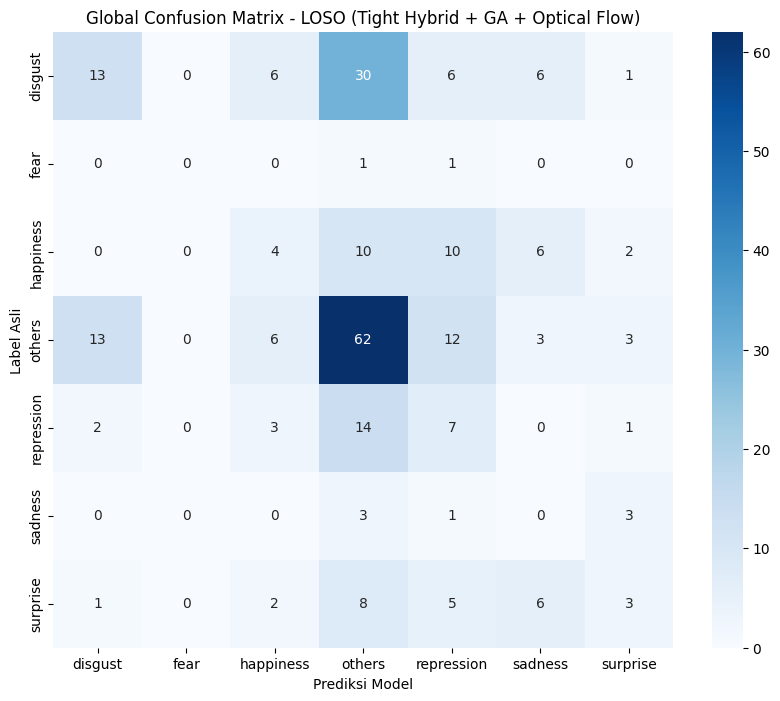

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score

os.makedirs("models", exist_ok=True)

fold_metrics = []
all_loso_true = []
all_loso_pred = []

print(f"Memulai Validasi Silang LOSO ({len(np.unique(g_arr))} Subjek)")
print("Tight Hybrid + GA | Backbone: ResNet18 (partial fine-tune) | Input: Optical Flow")
print(f"Chromosome (hasil GA): depth={best_chrom.mixer_depth}, heads={best_chrom.num_heads}, "
      f"dropout={best_chrom.dropout:.2f}, lr={best_chrom.lr:.0e}\n")

for fold, (train_val_idx, test_idx) in enumerate(logo.split(X_arr, y_arr, g_arr), 1):
    test_subj = g_arr[test_idx[0]]

    X_tv = X_arr[train_val_idx]
    y_tv = y_arr[train_val_idx]

    try:
        X_train, X_val, y_train, y_val = train_test_split(
            X_tv, y_tv, test_size=0.2, random_state=42, stratify=y_tv
        )
    except ValueError:
        X_train, X_val, y_train, y_val = train_test_split(
            X_tv, y_tv, test_size=0.2, random_state=42
        )

    X_test = X_arr[test_idx]
    y_test = y_arr[test_idx]

    train_dataset = MicroExpressionDataset(list(X_train), list(y_train), transform=train_transform)
    val_dataset = MicroExpressionDataset(list(X_val), list(y_val), transform=eval_transform)
    test_dataset = MicroExpressionDataset(list(X_test), list(y_test), transform=eval_transform)

    train_labels_int = [label_mapping[m] for m in y_train]
    class_counts = np.bincount(train_labels_int, minlength=7)
    sample_weights = [1.0 / (class_counts[m] + 1e-8) for m in train_labels_int]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Bangun model dari chromosome terbaik (GA); optimizer hanya pada parameter yang dilatih
    model = build_from_chrom(best_chrom).to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params, lr=best_chrom.lr, weight_decay=weight_decay)

    best_val_acc = -1.0
    patience_ctr = 0
    best_state = None

    for epoch in range(max_epochs):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()

        # ----- VALIDATION: dasar early-stopping & pemilihan model (BUKAN test) -----
        model.eval()
        correct_val = total_val = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                _, pred = torch.max(model(imgs), 1)
                total_val += lbls.size(0)
                correct_val += (pred == lbls).sum().item()
        val_acc = correct_val / total_val if total_val > 0 else 0.0

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), f"models/best_model_fold_{fold}.pth")

    # ----- EVALUASI TEST: sekali saja, model sudah final -----
    model.eval()
    fold_true, fold_pred = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, pred = torch.max(model(imgs), 1)
            fold_true.extend(lbls.cpu().numpy())
            fold_pred.extend(pred.cpu().numpy())

    test_acc = np.mean(np.array(fold_true) == np.array(fold_pred)) if fold_true else 0.0
    all_loso_true.extend(fold_true)
    all_loso_pred.extend(fold_pred)

    fold_metrics.append({
        "Fold": fold,
        "Subjek Diuji": test_subj,
        "Val Acc": f"{best_val_acc*100:.2f}%",
        "Akurasi Test": f"{test_acc*100:.2f}%",
        "N Test": len(fold_true)
    })

    print(f"Fold {fold:02d} | Subjek: {test_subj} | Val: {best_val_acc*100:5.2f}% | Test: {test_acc*100:6.2f}% | n={len(fold_true)}")

print(f"\n{'='*50}")
print("Pengujian LOSO Selesai")
df_loso = pd.DataFrame(fold_metrics)
display(df_loso)

# Metrik global lintas semua sampel (lebih andal utk data imbalance)
uf1 = f1_score(all_loso_true, all_loso_pred, average='macro')
global_acc = np.mean(np.array(all_loso_true) == np.array(all_loso_pred))
print(f"\nAkurasi global (semua sampel): {global_acc*100:.2f}%")
print(f"UF1 (macro-F1)              : {uf1:.4f}")

cm = confusion_matrix(all_loso_true, all_loso_pred, labels=list(range(7)))
cat_names = ['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise']
df_cm = pd.DataFrame(cm, index=cat_names, columns=cat_names)

plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli')
plt.title('Global Confusion Matrix - LOSO (Tight Hybrid + GA + Optical Flow)')
plt.show()

In [19]:
df_clean = df_loso.drop_duplicates(subset=['Subjek Diuji'], keep='last').copy()

df_clean['Akurasi Numeric'] = df_clean['Akurasi Test'].str.rstrip('%').astype(float)

mean_acc = df_clean['Akurasi Numeric'].mean()
std_acc = df_clean['Akurasi Numeric'].std()

table_summary = [
    {"Metrik": "Total Subjek", "Nilai": len(df_clean)},
    {"Metrik": "Rata-rata Akurasi (Mean)", "Nilai": f"{mean_acc:.2f}%"},
    {"Metrik": "Standar Deviasi", "Nilai": f"{std_acc:.2f}%"},
    {"Metrik": "Akurasi Tertinggi", "Nilai": f"{df_clean['Akurasi Numeric'].max():.2f}%"},
    {"Metrik": "Akurasi Terendah", "Nilai": f"{df_clean['Akurasi Numeric'].min():.2f}%"}
]

df_summary = pd.DataFrame(table_summary)
display(df_summary) 

,Metrik,Nilai
0,Total Subjek,26
1,Rata-rata Akurasi (Mean),30.40%
2,Standar Deviasi,26.17%
3,Akurasi Tertinggi,92.86%
4,Akurasi Terendah,0.00%


# Inference (Menggunakan Test Set)

In [20]:
import torch.nn.functional as F

# Muat salah satu model fold hasil training (Tight Hybrid + GA, backbone pretrained)
model = build_from_chrom(best_chrom).to(device)
model.load_state_dict(torch.load("models/best_model_fold_18.pth", map_location=device, weights_only=True))
model.eval()

table_data = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        probs_np = probs.cpu().numpy()
        lbls_np = lbls.cpu().numpy()
        pred_np = predicted.cpu().numpy()
        
        for idx in range(len(probs_np)):
            p = probs_np[idx]
            
            vp = p[2] + p[6]
            vn = p[3]
            vd = p[0] + p[1] + p[4] + p[5]
            
            vp_rendah = max(0.0, (0.5 - vp) / 0.5) if vp <= 0.5 else 0.0
            vp_sedang = max(0.0, min(vp / 0.5, (1.0 - vp) / 0.5))
            vp_tinggi = max(0.0, (vp - 0.5) / 0.5) if vp >= 0.5 else 0.0
            
            vn_rendah = max(0.0, (0.5 - vn) / 0.5) if vn <= 0.5 else 0.0
            vn_sedang = max(0.0, min(vn / 0.5, (1.0 - vn) / 0.5))
            vn_tinggi = max(0.0, (vn - 0.5) / 0.5) if vn >= 0.5 else 0.0
            
            vd_rendah = max(0.0, (0.5 - vd) / 0.5) if vd <= 0.5 else 0.0
            vd_sedang = max(0.0, min(vd / 0.5, (1.0 - vd) / 0.5))
            vd_tinggi = max(0.0, (vd - 0.5) / 0.5) if vd >= 0.5 else 0.0
            
            w1 = min(vp_tinggi, vd_rendah)
            w2 = min(vn_tinggi, vp_rendah, vd_rendah)
            w3 = vd_tinggi
            w4 = min(vp_sedang, vn_sedang)
            w5 = min(vp_sedang, vd_sedang)
            w6 = min(vn_sedang, vd_sedang)
            
            total_w = w1 + w2 + w3 + w4 + w5 + w6
            score = ((w1 * 90.0) + (w2 * 60.0) + (w3 * 25.0) + (w4 * 70.0) + (w5 * 50.0) + (w6 * 40.0)) / total_w if total_w > 0 else 50.0
            
            table_data.append({
                "Label Asli": categories[lbls_np[idx]],
                "Prediksi": categories[pred_np[idx]],
                "Positif (Vp)": f"{vp*100:.1f}%",
                "Netral (Vn)": f"{vn*100:.1f}%",
                "Negatif (Vd)": f"{vd*100:.1f}%",
                "Engagement Score": round(score, 2)
            })

df_results = pd.DataFrame(table_data)
df_results.index += 1
display(df_results.head(20))

df_results.to_csv("detailed_predictions.csv", index_label="No")

,Label Asli,Prediksi,Positif (Vp),Netral (Vn),Negatif (Vd),Engagement Score
1,happiness,happiness,99.8%,0.0%,0.2%,89.830002
2,others,others,0.1%,74.6%,25.3%,49.880001
3,others,others,1.3%,50.4%,48.3%,41.189999
4,others,others,0.1%,94.9%,5.0%,58.009998
5,disgust,disgust,0.0%,1.2%,98.8%,25.370001
6,disgust,disgust,0.0%,0.5%,99.5%,25.170000
7,others,disgust,0.0%,0.2%,99.8%,25.080000
8,happiness,happiness,98.6%,0.0%,1.4%,88.849998
9,disgust,disgust,0.0%,5.0%,94.9%,26.530001
10,sadness,sadness,0.0%,0.0%,100.0%,25.020000


In [21]:
temperature = 2.0
table_data = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        
        outputs = model(imgs)
        probs = F.softmax(outputs / temperature, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        probs_np = probs.cpu().numpy()
        lbls_np = lbls.cpu().numpy()
        pred_np = predicted.cpu().numpy()
        
        for idx in range(len(probs_np)):
            p = probs_np[idx]
            
            vp = p[2] + p[6]
            vn = p[3]
            vd = p[0] + p[1] + p[4] + p[5]
            
            vp_rendah = max(0.0, (0.5 - vp) / 0.5) if vp <= 0.5 else 0.0
            vp_sedang = max(0.0, min(vp / 0.5, (1.0 - vp) / 0.5))
            vp_tinggi = max(0.0, (vp - 0.5) / 0.5) if vp >= 0.5 else 0.0
            
            vn_rendah = max(0.0, (0.5 - vn) / 0.5) if vn <= 0.5 else 0.0
            vn_sedang = max(0.0, min(vn / 0.5, (1.0 - vn) / 0.5))
            vn_tinggi = max(0.0, (vn - 0.5) / 0.5) if vn >= 0.5 else 0.0
            
            vd_rendah = max(0.0, (0.5 - vd) / 0.5) if vd <= 0.5 else 0.0
            vd_sedang = max(0.0, min(vd / 0.5, (1.0 - vd) / 0.5))
            vd_tinggi = max(0.0, (vd - 0.5) / 0.5) if vd >= 0.5 else 0.0
            
            w1 = min(vp_tinggi, vd_rendah)
            w2 = min(vn_tinggi, vp_rendah, vd_rendah)
            w3 = vd_tinggi
            w4 = min(vp_sedang, vn_sedang)
            w5 = min(vp_sedang, vd_sedang)
            w6 = min(vn_sedang, vd_sedang)
            
            total_w = w1 + w2 + w3 + w4 + w5 + w6
            score = ((w1 * 90.0) + (w2 * 60.0) + (w3 * 25.0) + (w4 * 70.0) + (w5 * 50.0) + (w6 * 40.0)) / total_w if total_w > 0 else 50.0
            
            table_data.append({
                "Label Asli": categories[lbls_np[idx]],
                "Prediksi": categories[pred_np[idx]],
                "Positif (Vp)": f"{vp*100:.1f}%",
                "Netral (Vn)": f"{vn*100:.1f}%",
                "Negatif (Vd)": f"{vd*100:.1f}%",
                "Engagement Score": round(score, 2)
            })

df_results = pd.DataFrame(table_data)
df_results.index += 1
display(df_results.head(20))
df_results.to_csv("detailed_predictions_temperature_2.0.csv", index_label="No")

,Label Asli,Prediksi,Positif (Vp),Netral (Vn),Negatif (Vd),Engagement Score
1,happiness,happiness,99.3%,0.0%,0.7%,89.410004
2,others,others,0.2%,70.3%,29.4%,48.279999
3,others,others,2.4%,49.2%,48.3%,41.820000
4,others,others,0.3%,91.8%,8.0%,56.840000
5,disgust,disgust,0.0%,2.4%,97.5%,25.790001
6,disgust,disgust,0.1%,1.2%,98.8%,25.440001
7,others,disgust,0.0%,0.6%,99.3%,25.240000
8,happiness,happiness,96.8%,0.1%,3.1%,87.410004
9,disgust,disgust,0.0%,7.9%,92.0%,27.440001
10,sadness,sadness,0.2%,0.0%,99.8%,25.100000


In [1]:
print("test")

test
